# Comparison of the percentage of highly-conserved coding/noncoding nucleotides
Conservation: phastCons
Coding/Noncoding: CDS (start codon - stop codon) of MANE transcript - coding; all the rest: noncoding

In [1]:
import pandas as pd
import pyBigWig
import pybedtools
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import re

import matplotlib as mpl
from matplotlib import font_manager

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

In [2]:
cons_path = "/media/rna/fy2306/hg38.phastCons100way.bw"
mane_gtf_path = "/media/scratch/fy2306/genomes/hg38/MANE/release_1.4/MANE.GRCh38.v1.4.refseq_genomic.gtf"

In [3]:
def calculate_conserved_nucleotide(bw, myc_gene, myc_cds, threshold):
	
	total_bases = 0
	total_conserved = 0
	# gene span of 
	scores = bw.values(myc_gene['chrom'], myc_gene['start'] - 1, myc_gene['end'])
	scores = np.nan_to_num(np.array(scores), nan=0.0)
	total_bases += len(scores)
	total_conserved += np.sum(scores >= threshold)
	# bigWig and pybigwig use 0-based half-open coordinates

	cds_conserved = 0

	for _, row in myc_cds.iterrows():
		chrom, start, end = row['chrom'], int(row['start']), int(row['end'])	# now 0-based start
		if chrom not in bw.chroms():
			continue
		vals = bw.values(chrom, start, end)
		vals = np.nan_to_num(np.array(vals), nan=0.0)                  
		cds_conserved += np.sum(vals >= threshold)

	coding_pct = 100 * cds_conserved / total_conserved
	noncoding_pct = 100 - coding_pct
	noncoding_conserved = total_conserved - cds_conserved
	
	return coding_pct, noncoding_pct, cds_conserved, noncoding_conserved

In [4]:
def plot_conserved_nucleotide(thresholds):

	# load in bw
	bw = pyBigWig.open(cons_path)

	# ENST00000377970.6
	myc_gene = {"chrom": "chr8", "start": 127736084, "end": 127741434}	# 1-based
	myc_cds = pd.DataFrame({
    'chrom': ['chr8', 'chr8'],
    'start': [127738262, 127740395],
    'end': [127739019, 127740958]
	})	# 0-based, from table browser bed file

	print(myc_cds)

	results = []

	for threshold in thresholds:
		print(threshold)
		coding_pct, noncoding_pct, coding_conserved, noncoding_conserved = calculate_conserved_nucleotide(bw, myc_gene, myc_cds, threshold)
		results.append({'threshold': threshold, 'coding': coding_pct, 'noncoding': noncoding_pct, 'coding_number': coding_conserved, 'noncoding_number': noncoding_conserved})

	df = pd.DataFrame(results, columns=['threshold', 'coding', 'noncoding', 'coding_number', 'noncoding_number'])
	print(df)

	plt.figure(figsize=(4, 2.5))
	plt.stackplot(
		df['threshold'],
		df['coding'],
		df['noncoding'],
		labels=['Coding', 'Noncoding'],
		colors=['#FF0066', '#000000']
	)

	plt.legend().set_visible(False)
	plt.xlabel('Threshold for conserved base pair', fontsize=13)
	plt.ylabel(r'Conserved base pair %', fontsize=13)
	plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
	plt.xlim(df['threshold'].min(), df['threshold'].max())
	plt.yticks(fontsize=12)
	plt.ylim(0,101)
	plt.gca().spines['top'].set_visible(False)
	plt.gca().spines['right'].set_visible(False)
	# add text
	x_loc = 0.2

	plt.text(x_loc, df['coding'].iloc[1] / 2, 'Coding', color='white', fontsize=13,
			ha='center', va='center', fontweight='bold')
	plt.text(x_loc, df['noncoding'].iloc[1] / 2 + df['coding'].iloc[1], 'Noncoding', color='white', fontsize=13,
			ha='center', va='center', fontweight='bold')
	plt.tight_layout()
	plt.savefig("/media/scratch/fy2306/projects/base_editing/plots/miscellaneous/conserved_basepair.myc.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

  chrom      start        end
0  chr8  127738262  127739019
1  chr8  127740395  127740958
0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
1
    threshold     coding  noncoding  coding_number  noncoding_number
0         0.0  24.668286  75.331714           1320              4031
1         0.1  44.050343  55.949657           1155              1467
2         0.2  45.534290  54.465710           1142              1366
3         0.3  46.441948  53.558052           1116              1287
4         0.4  47.486034  52.513966           1105              1222
5         0.5  48.397150  51.602850           1087              1159
6         0.6  49.674721  50.325279           1069              1083
7         0.7  50.576369  49.423631           1053              1029
8         0.8  51.278195  48.721805           1023               972
9         0.9  52.536038  47.463962            984               889
10        1.0  59.202454  40.797546            772               532


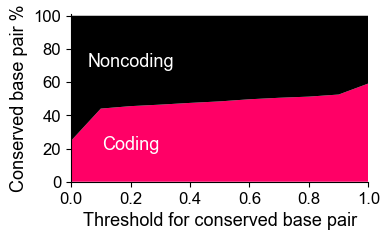

In [5]:
plot_conserved_nucleotide([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])